In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [2]:
X,y = load_diabetes(return_X_y=True) #Don’t give me the whole object, just give me features (X) and target (y) directly.”

In [3]:

X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [4]:
X.shape

(442, 10)

In [5]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [6]:
y.shape

(442,)

<h2>Using Sklearn linear regression
</h2>

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
print(X_train.shape)
print(X_test.shape)


(353, 10)
(89, 10)


In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
reg = LinearRegression()

In [12]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = reg.predict(X_test)

In [14]:
from sklearn.metrics import r2_score

In [15]:
r2_score(y_test,y_pred)

0.4399338661568969

In [16]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [17]:
reg.intercept_

np.float64(151.88331005254167)

<h2>Making our own Linear Regression Class</h2>

In [ ]:
| Part      | Meaning                                 |
| --------- | --------------------------------------- |
| `X_train` | Your feature matrix                     |
| `0`       | Insert at column index 0 (first column) |
| `1`       | Value to insert                         |
| `axis=1`  | Insert column-wise                      |


In [18]:
class MeraLR:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1) #It adds a new column of 1s at the start of your feature matrix.
        
        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred
        

In [19]:
lr = MeraLR()

In [20]:
lr.fit(X_train,y_train)

In [21]:
X_train.shape

(353, 10)

In [22]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [23]:
y_pred = lr.predict(X_test)

In [24]:
r2_score(y_test,y_pred)

0.43993386615689656

In [25]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [26]:
lr.intercept_

np.float64(151.88331005254167)

<h2>Second File</h2>

In [2]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

make_regression is a data generator from scikit-learn used to create a fake regression dataset.

In [3]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
     

In [4]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [5]:
df.shape

(100, 3)

In [6]:
df.head()

,feature1,feature2,target
0,-0.420015,-0.363678,-5.735879
1,0.976063,0.403495,181.011302
2,-1.025427,-0.901679,-109.099463
3,-0.425613,0.788274,-8.929662
4,1.211724,0.898448,128.413690


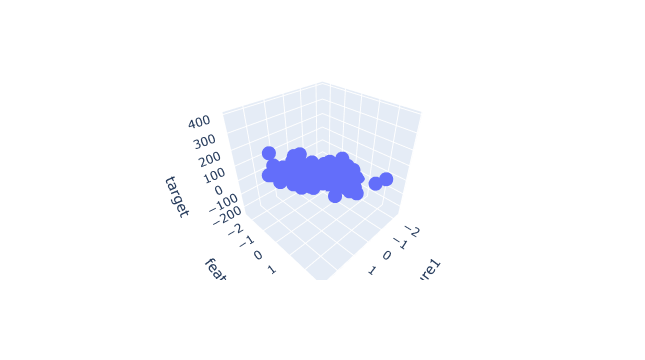

In [7]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [8]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)
     

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(X_test)


In [13]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 56.631524381392694
MSE 5250.39672888591
R2 score 0.6903483716974994


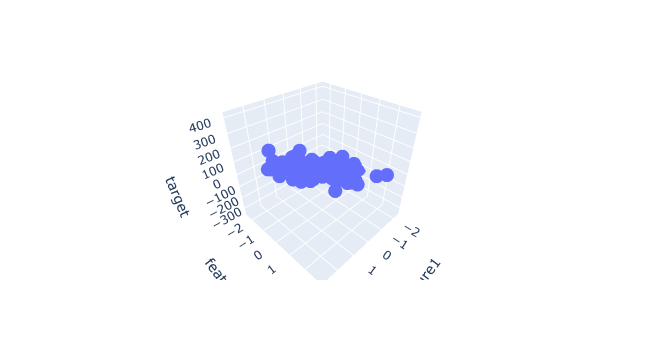

In [15]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

x = np.linspace(df['feature1'].min(), df['feature1'].max(), 10)
y = np.linspace(df['feature2'].min(), df['feature2'].max(), 10)

xGrid, yGrid = np.meshgrid(x, y)

final = np.c_[xGrid.ravel(), yGrid.ravel()]

z = lr.predict(final).reshape(10,10)

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.6, showscale=False))

fig.show()


In [46]:
lr.coef_

array([50.019053  , 67.63072695])

In [47]:
lr.intercept_
     

np.float64(-2.986090031231887)